In [1]:
import pandas as pd 

train = pd.read_csv('House_price/train.csv')

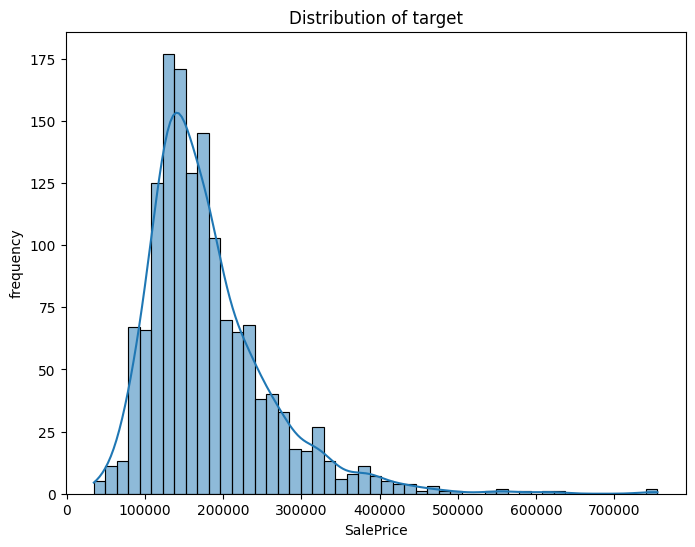

1.8828757597682129


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns 

plt.figure(figsize=(8,6))
sns.histplot(train['SalePrice'], kde=True )
plt.title('Distribution of target')
plt.xlabel('SalePrice')
plt.ylabel('frequency')
plt.show()

skewness = train['SalePrice'].skew()
print(skewness)

Từ biểu đồ và giá trị 
skewness (giá trị hiển thị độ chênh lệch của target) lớn hơn 1 nên suy ra độ phân phối của target không đồng đều, trong trường hợp này là numerical với nhiều outlier, cách ổn định tốt là dùng log transform và vẽ lại đồ thị để xem. 

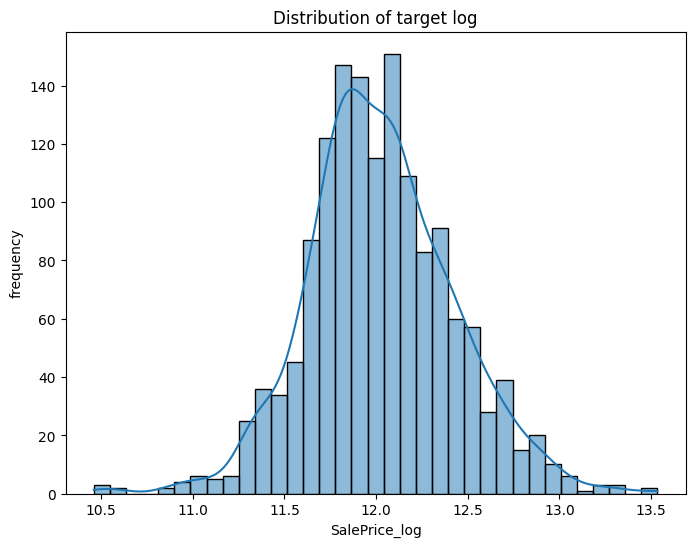

0.12134661989685333


In [3]:
import numpy as np 

train['SalePrice_log'] = np.log1p(train['SalePrice'])

#draw the histogram again 
plt.figure(figsize=(8,6))
sns.histplot(train['SalePrice_log'], kde=True)
plt.title('Distribution of target log')
plt.xlabel('SalePrice_log')
plt.ylabel('frequency')
plt.show()

skewness = train['SalePrice_log'].skew()
print(skewness)

Nhờ vào cách transform của log mà giờ phân phối đã ổn định hơn theo chiều hướng tốt. 
Note: 
1) do đã transform giá trị target, nên từ giờ ta phải sử dụng SalePrice_log thay vì SalePrice (có thể xóa đi)
2) khi train xong mô hình dự đoán, giá trị trả về vẫn sẽ là ở scale của log, nên cần biến đổi ngược lại để ra giá trị nguyên gốc ban đầu

Tiếp theo ta liệt kê các giá trị missing trong file train.csv này. 

In [4]:
from pandas._libs import missing


numerical = train.select_dtypes(include=['int64', 'float64']).columns 
categorical = train.select_dtypes(include='object').columns 

def missing_value(df, feature): 
    total = df[feature].isnull().sum()
    percentage = (total / len(df)) * 100
    stats = pd.DataFrame({'total_miss': total, 'percent' : percentage})
    stats = stats[stats['total_miss'] > 0]
    return stats 

num = missing_value(train, numerical)
print('for numerical features: ')
print(num)

cat = missing_value(train, categorical)
print('\n for categorical features: ')
print(cat)

for numerical features: 
             total_miss    percent
LotFrontage         259  17.739726
MasVnrArea            8   0.547945
GarageYrBlt          81   5.547945

 for categorical features: 
              total_miss    percent
Alley               1369  93.767123
MasVnrType           872  59.726027
BsmtQual              37   2.534247
BsmtCond              37   2.534247
BsmtExposure          38   2.602740
BsmtFinType1          37   2.534247
BsmtFinType2          38   2.602740
Electrical             1   0.068493
FireplaceQu          690  47.260274
GarageType            81   5.547945
GarageFinish          81   5.547945
GarageQual            81   5.547945
GarageCond            81   5.547945
PoolQC              1453  99.520548
Fence               1179  80.753425
MiscFeature         1406  96.301370


Khi nhìn vào chỗ dữ liệu này chúng ta có thể để ý thấy 5 features liên quan đến Garage của các căn nhà đều missing 81, vậy nó có thể mang nghĩa là nhà đó không có garage, nên chúng ta cần kiểm tra xem liệu chúng có missing cùng một hàng không. 

In [5]:
garage_missing = train[['GarageYrBlt', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond']]
total_garage_miss = garage_missing.isnull().all(axis = 1)
print(total_garage_miss.sum())

81


Yup, chúng missing cùng một hàng, suy ra là các căn nhà đó đều không có garage. Vì số lượng missing cũng đủ để phân loại thành một label riêng trong feature đó, nên ta sẽ thay giá trị missing đó thành một label riêng "NoGarage" cho 4 features categorical và 0 cho numerical feature này luôn. 

In [6]:
train['GarageYrBlt'] = train['GarageYrBlt'].fillna(0)

garage_miss_cat = ['GarageType', 'GarageFinish', 'GarageQual', 'GarageCond']
for col in garage_miss_cat:
    train[col] = train[col].fillna("NoGarage")

for col in garage_miss_cat:
    check_missing_left = (train[col] == "NoGarage").sum()
    print (check_missing_left)

81
81
81
81


Feature tiếp theo lọt vào mắt mình đó là Basement (tầng hầm) 

BsmtQual                 37   2.534247

BsmtCond                 37   2.534247

BsmtExposure             38   2.602740

BsmtFinType1             37   2.534247

BsmtFinType2             38   2.602740

thông thường mình sẽ bỏ các features có tỉ lệ missing dưới 3% hoặc điền nó bằng median hoặc mode, nhưng vì đây đều là các features có liên quan đến nhau nên có thể về sau tất cả gộp lại vẫn có ích, nên ta sẽ cho các features này một label riêng là NoBasement, mà trước đó cần kiểm tra xem có miss cùng 1 hàng không đã. 

In [7]:
Basement_checking = train[['BsmtQual', 'BsmtCond', 'BsmtFinType1', 'BsmtExposure', 'BsmtFinType2']]
total_basemiss = Basement_checking.isnull().all(axis = 1)
print(total_basemiss.sum())

37


Dựa vào thống kê ta thấy chúng đều cùng missing 37 hàng như nhau là do không có basement để đánh giá. 
2 features còn lại đại diện cho căn nhà có tầng hầm nhưng 1 nhà là không thông gió và 1 nhà là không có tầng hầm 2. 
May mắn ở chỗ, 2 features này đều có label riêng của nó để thể hiện là không có, nên ta chỉ việc điền vào thôi. 

In [8]:
basement_filling = ['BsmtQual', 'BsmtCond', 'BsmtFinType1', 'BsmtExposure', 'BsmtFinType2']
for col in basement_filling:
    train[col] = train[col].fillna("NoBasement")

train.loc[train['BsmtExposure'] == "NoBasement", 'BsmtExposure'] == "No"
train.loc[train['BsmtFinType2'] == "NoBasement", 'BsmtFinType2'] == "Unf"

print(train[basement_filling].isnull().sum())

BsmtQual        0
BsmtCond        0
BsmtFinType1    0
BsmtExposure    0
BsmtFinType2    0
dtype: int64


Tiếp theo là các giá trị này 
MasVnrType             872   59.726027

Electrical               1    0.068493

FireplaceQu            690   47.260274

Fence               1179   80.753425

với Electrical thì điền giá trị xuất hiện nhiều nhất cho nó (vì tỉ lệ missing quá nhỏ, dễ gây minor case nếu ta thêm label mới)

Phần ốp gạch đá và lò sưởi là do nhà không có nên ta điền label tương ứng vào 
(vì tỉ lệ missing cũng vừa đủ lớn)


Fence                 1179   80.753425
(tỷ lệ ở mức cao nhất có thể chấp nhận được, nên mình sẽ điền label vào) - vẫn còn nhiều bước lọc feature nên model vẫn sẽ ổn định


Alley                 1369   93.767123

PoolQC                1453   99.520548

MiscFeature           1406   96.301370

(3 features này có tỷ lệ missing cực cao do bản chất hiếm có của chúng, vì thể ta tạm bỏ qua không đem đi train), và bỏ cả Target SalePrice đi luôn.

In [9]:
train['Electrical'] = train['Electrical'].fillna(train['Electrical'].mode()[0])

train['MasVnrType'] = train['MasVnrArea'].fillna("None")

train["FireplaceQu"] = train["FireplaceQu"].fillna("NoFireplace")

train['Fence'] = train['Fence'].fillna("NoFence")

drop_cat_features = ['Alley', 'PoolQC', 'MiscFeature', 'SalePrice']
train = train.drop(columns=drop_cat_features, errors = 'ignore')

Vậy là ta đã xử lý xong tất cả các giá trị missing trong categorical feature, giờ đến phần phân tích dữ liệu. Để đơn giản, mình chỉ hướng dẫn 2 phương pháp xử lý. 
1) Sử dụng ANOVA test để so sánh mức độ tương quan giữa các features này với target (SalePrice_log), cái nào mang giá trị p_value nhỏ hơn 0.5 thì bỏ 
2) Cramer's V value để phát hiện những cặp features có khả năng mang tính trùng lặp cao, làm cho mô hình nặng và rối, nên bỏ 1 trong 2 cho mỗi cặp 

Trước hết là ANOVA test. 

In [10]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

categorical = train.select_dtypes(include='object').columns 
print(len(categorical))

anova_results = {}

for feature in categorical: 
    try: 
        model = ols(f'SalePrice_log ~ C({feature})', data=train).fit() 
        # sau khi định nghĩa thì cần ước lượng tham số để tính toán hồi quy, nên ta dùng .fit()
        # print(model.summary())

        #Create ANOVA table, mô hình tính toán khá phức tạp nên ta có thể tìm hiểu sâu hơn từ từ 
        anova_table = sm.stats.anova_lm(model, typ = 2)
        p_value = anova_table.loc[f"C({feature})", "PR(>F)"]
        anova_results[feature] = p_value

    except Exception as e:
        print(f"Không chạy được ANOVA cho {feature}: {e}")

anova_df = pd.DataFrame.from_dict(anova_results, orient="index", columns=['p_value'])
# strong_features = anova_df[anova_df['p_value'] < 0.05].sort_values('p_value')

# print("here are top strongest 15 categorical features")
# print(strong_features)


weak_features = anova_df[anova_df['p_value'] > 0.01].sort_values('p_value', ascending=False)
print(weak_features)

40
             p_value
Utilities   0.629609
LandSlope   0.338834
Street      0.028380
Condition2  0.013820


Dựa vào kết quả thống kê ta bỏ được 2 features là Utilities và LandSlope. Tổng số lượng categorical features bây giờ là còn 38. 
Tiếp theo là Cramer's V value để phát hiện các cặp mang tính trùng lặp. 

In [11]:
import scipy.stats as stats

drop_cat_feature2 = ['Utilities', 'LandSlope']
train = train.drop(columns=drop_cat_feature2, errors = 'ignore')

categorical = train.select_dtypes(include= 'object').columns
print(len(categorical))

def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = stats.chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2/n
    r,k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))    
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1),(rcorr-1)))



cramers_results = {}
for i, feat1 in enumerate(categorical):
    for feat2 in categorical[i+1:]:
        try:
            v = cramers_v(train[feat1], train[feat2])
            cramers_results[(feat1, feat2)] = v
        except Exception as e:
            print(f"Không tính được cho {feat1} và {feat2}: {e}")


cramers_df = pd.DataFrame.from_dict(cramers_results, orient='index', columns=['Cramers_V'])
cramers_df = cramers_df.sort_values('Cramers_V', ascending = False)

print("\n Top 20 cặp biến categorical có Cramér's V cao nhất:")
print(cramers_df.head(20))

38

 Top 20 cặp biến categorical có Cramér's V cao nhất:
                              Cramers_V
(Exterior1st, Exterior2nd)     0.758884
(GarageQual, GarageCond)       0.704239
(GarageType, GarageFinish)     0.684925
(MSZoning, Neighborhood)       0.640629
(GarageFinish, GarageQual)     0.588926
(GarageFinish, GarageCond)     0.586373
(BsmtQual, BsmtFinType1)       0.576612
(ExterQual, KitchenQual)       0.546038
(Foundation, BsmtQual)         0.531379
(BsmtQual, BsmtCond)           0.526751
(BsmtExposure, BsmtFinType1)   0.521574
(BsmtQual, BsmtExposure)       0.520873
(BsmtCond, BsmtFinType1)       0.506968
(BsmtQual, BsmtFinType2)       0.500016
(BsmtCond, BsmtExposure)       0.495026
(BsmtCond, BsmtFinType2)       0.494448
(BsmtExposure, BsmtFinType2)   0.490602
(Neighborhood, ExterQual)      0.485240
(SaleType, SaleCondition)      0.470819
(Neighborhood, BsmtQual)       0.465577


Khoảng giá trị của phương pháp Cramer's V là 0 đến 1, càng gần 1 thì mức độ tương quan của cặp giá trị đó càng mạnh, nên ta cần phải bỏ 1 trong 2. 
Về giá trị ngưỡng, các bạn có thể chọn 0.4 hoặc 0.5 tùy thích, nhưng note một điều, chỉ nên xem xét bỏ khi giá trị chúng thật sự cao và 2 features đó đều cùng trỏ về 1 tính năng (vd: đều nói về tầng hầm, đều nói về garage, ...) 

Exterior2nd (giữ Exterior1st).

GarageCond (giữ GarageQual hoặc GarageFinish).

GarageType (giữ GarageFinish).

MSZoning (giữ Neighborhood).

BsmtFinType1, BsmtFinType2, BsmtCond (giữ BsmtQual và BsmtExposure).

SaleCondition (giữ SaleType).

Đây là những features mình sẽ bỏ để tính lại giá trị Cramer's V 

In [12]:
drop_cat_feature3 = ['Exterior2nd', 'GarageCond', 'GarageType', 'MSZoning', 'BsmtFinType1', 'BsmtFinType2', 'BsmtCond', 'SaleCondition']
train = train.drop(columns=drop_cat_feature3, errors = 'ignore')

categorical = train.select_dtypes(include='object').columns
print(len(categorical))

def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = stats.chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2/n
    r,k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))    
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1),(rcorr-1)))



cramers_results = {}
for i, feat1 in enumerate(categorical):
    for feat2 in categorical[i+1:]:
        try:
            v = cramers_v(train[feat1], train[feat2])
            cramers_results[(feat1, feat2)] = v
        except Exception as e:
            print(f"Không tính được cho {feat1} và {feat2}: {e}")


cramers_df = pd.DataFrame.from_dict(cramers_results, orient='index', columns=['Cramers_V'])
cramers_df = cramers_df.sort_values('Cramers_V', ascending = False)

print("\n Top 20 cặp biến categorical có Cramér's V cao nhất:")
print(cramers_df.head(20))

30

 Top 20 cặp biến categorical có Cramér's V cao nhất:
                              Cramers_V
(GarageFinish, GarageQual)     0.588926
(ExterQual, KitchenQual)       0.546038
(Foundation, BsmtQual)         0.531379
(BsmtQual, BsmtExposure)       0.520873
(Neighborhood, ExterQual)      0.485240
(Neighborhood, BsmtQual)       0.465577
(ExterQual, BsmtQual)          0.464362
(Heating, CentralAir)          0.460820
(RoofStyle, RoofMatl)          0.458024
(Neighborhood, KitchenQual)    0.444320
(BsmtQual, KitchenQual)        0.422418
(CentralAir, Electrical)       0.421239
(Neighborhood, BldgType)       0.418752
(Neighborhood, Foundation)     0.417266
(Neighborhood, GarageFinish)   0.416955
(Foundation, BsmtExposure)     0.409708
(RoofMatl, MasVnrType)         0.406632
(Neighborhood, CentralAir)     0.382148
(HeatingQC, CentralAir)        0.378677
(ExterQual, Foundation)        0.371131


Vẫn còn tồn tại cặp giá trị cao và cùng trỏ về 1 tính chất, nên mình sẽ bỏ tiếp 

GarageQual (giữ GarageFinish).

ExterQual (giữ KitchenQual).

Foundation (giữ BsmtQual).

BsmtExposure (giữ BsmtQual).

Heating (giữ CentralAir).

RoofMatl (giữ RoofStyle).

Electrical (giữ CentralAir).

BldgType (giữ Neighborhood).

MasVnrType (giữ RoofStyle).

In [13]:
drop_cat_feature4 = ['GarageQual', 'ExterQual', 'Foundation', 'BsmtExposure', 'Heating', 'RoofMatl', 'Electrical', 'BldgType', 'MasVnrType']
train = train.drop(columns=drop_cat_feature4, errors = 'ignore')

categorical = train.select_dtypes(include='object').columns
print(len(categorical))

def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = stats.chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2/n
    r,k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))    
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1),(rcorr-1)))



cramers_results = {}
for i, feat1 in enumerate(categorical):
    for feat2 in categorical[i+1:]:
        try:
            v = cramers_v(train[feat1], train[feat2])
            cramers_results[(feat1, feat2)] = v
        except Exception as e:
            print(f"Không tính được cho {feat1} và {feat2}: {e}")


cramers_df = pd.DataFrame.from_dict(cramers_results, orient='index', columns=['Cramers_V'])
cramers_df = cramers_df.sort_values('Cramers_V', ascending = False)

print("\n Top 21 cặp biến categorical có Cramér's V cao nhất:")
print(cramers_df.head(21))

21

 Top 21 cặp biến categorical có Cramér's V cao nhất:
                              Cramers_V
(Neighborhood, BsmtQual)       0.465577
(Neighborhood, KitchenQual)    0.444320
(BsmtQual, KitchenQual)        0.422418
(Neighborhood, GarageFinish)   0.416955
(Neighborhood, CentralAir)     0.382148
(HeatingQC, CentralAir)        0.378677
(LandContour, Neighborhood)    0.359864
(Exterior1st, CentralAir)      0.348793
(CentralAir, KitchenQual)      0.342675
(BsmtQual, GarageFinish)       0.340708
(CentralAir, PavedDrive)       0.335635
(CentralAir, GarageFinish)     0.325547
(KitchenQual, GarageFinish)    0.319987
(HeatingQC, KitchenQual)       0.318353
(Condition2, RoofStyle)        0.311197
(Neighborhood, PavedDrive)     0.309300
(Neighborhood, FireplaceQu)    0.304093
(Exterior1st, BsmtQual)        0.297457
(Neighborhood, HeatingQC)      0.296491
(Neighborhood, HouseStyle)     0.294001
(Exterior1st, KitchenQual)     0.290096


Ngưỡng mình chọn là 0.5, đồng thời ta không còn cặp nào cùng trỏ về 1 tính chất và mang giá trị cao nữa, nên coi như phần phân tích categorical đến đây là xong. Giờ ta có thể chuyển qua phân tích Numerical. 

for numerical features: 
             total_miss    percent

LotFrontage         259  17.739726
MasVnrArea            8   0.547945

Với các giá trị numerical mà có tỉ lệ missing ít (với mình là dưới 20%) thì luôn khuyến khích điền bằng median của feature đó. 

MasVnrArea là diện tích ốp gạch đá, trong dữ liệu ta có giá trị = 0 đại diện cho nhà đó không có ốp, nhưng lý do tại sao lại có 8 giá trị missing thì chắc chắn không phải là 8 căn nhà đó không ốp, mà có thể do không đo thật - vì thế ta có thể điền bằng median của nó. 

LotFrontage là chiều dài mặt tiền từ đường đến nhà, 1 trick nhỏ và thực tế cho mọi người là ta dựa vào feature Neighborhood để điền median cho nó. Trên thực tế, chiều dài từ đường đến nhà trong cùng một khu phố (Neighborhood) thường bằng nhau, vì làm gì có ai dám xây lấn ra ngoài đường chứ. 

In [15]:
# Điền LotFrontage bằng median theo Neighborhood
train['LotFrontage'] = train.groupby('Neighborhood')['LotFrontage'].transform(lambda x: x.fillna(x.median()))

train['MasVnrArea'] = train['MasVnrArea'].fillna(train['MasVnrArea'].median())

numerical = train.select_dtypes(include=['int64', 'float64']).columns
num = missing_value(train, numerical)
print(num)

Empty DataFrame
Columns: [total_miss, percent]
Index: []


Ta đã xử lý xong missing. Tiếp theo đến phân tích dữ liệu cho các numerical features này. Để đơn giản, mình cũng chỉ giới thiệu 2 phương pháp phân tích:
1) Tính độ correlation giữa các features với nhau để tránh trường hợp multicolinear (đa cộng tuyến) xảy ra khi dùng mô hình tuyến tính 
2) Tính giá trị VIF - để xác nhận trường hợp đa cộng tuyến có dễ xảy ra không, nếu có thì chỉ dùng được mô hình phi tuyến 

Đầu tiên là tính mức độ tương quan (correlation) giữa các features 

In [17]:
corr_matrix = train.corr(numeric_only = True)

corr_pairs = (corr_matrix
              .abs()    #simplify to positive values only 
              .unstack()  #change it to a table 
              .sort_values(ascending = False)   #arrange in order
              .drop_duplicates())    #no need to see correlation of a feature with itself 

corr_pairs = corr_pairs[corr_pairs > 0.5]
print(corr_pairs)

Id             Id               1.000000
GarageCars     GarageArea       0.882475
TotRmsAbvGrd   GrLivArea        0.825489
TotalBsmtSF    1stFlrSF         0.819530
SalePrice_log  OverallQual      0.817185
               GrLivArea        0.700927
2ndFlrSF       GrLivArea        0.687501
GarageCars     SalePrice_log    0.680625
TotRmsAbvGrd   BedroomAbvGr     0.676620
SalePrice_log  GarageArea       0.650888
BsmtFinSF1     BsmtFullBath     0.649212
FullBath       GrLivArea        0.630012
2ndFlrSF       TotRmsAbvGrd     0.616423
SalePrice_log  TotalBsmtSF      0.612134
2ndFlrSF       HalfBath         0.609707
OverallQual    GarageCars       0.600671
GarageCars     GarageYrBlt      0.598005
1stFlrSF       SalePrice_log    0.596981
SalePrice_log  FullBath         0.594771
OverallQual    GrLivArea        0.593007
YearBuilt      YearRemodAdd     0.592855
               SalePrice_log    0.586570
OverallQual    YearBuilt        0.572323
1stFlrSF       GrLivArea        0.566024
YearRemodAdd   S

Yup, với chừng này features có độ tương quan mạnh với nhau thì bắt buộc phải bỏ bớt để mô hình không bị phức tạo và rối trong việc ra quyết định. 
Chúng ta sẽ bỏ những features này ['GarageArea', 'TotRmsAbvGrd', '1stFlrSF', 'BedroomAbvGr', '2ndFlrSF', 'BsmtFullBath']
Feature 'Id' cần giữ lại để làm số thứ tự điền giá trị dự đoán vào file và nộp. 

In [19]:
drop_num_feature = ['GarageArea', 'TotRmsAbvGrd', '1stFlrSF', 'BedroomAbvGr', '2ndFlrSF', 'BsmtFullBath']
train = train.drop(columns= drop_num_feature, errors= 'ignore')

#Recalculate correlation pairs 
corr_matrix = train.corr(numeric_only= True)
corr_pairs = (corr_matrix
              .abs()
              .unstack()
              .sort_values(ascending = False)
              .drop_duplicates())

corr_pairs = corr_pairs[corr_pairs > 0.5]
print(corr_pairs)

Id             Id               1.000000
OverallQual    SalePrice_log    0.817185
SalePrice_log  GrLivArea        0.700927
GarageCars     SalePrice_log    0.680625
FullBath       GrLivArea        0.630012
SalePrice_log  TotalBsmtSF      0.612134
OverallQual    GarageCars       0.600671
GarageCars     GarageYrBlt      0.598005
FullBath       SalePrice_log    0.594771
OverallQual    GrLivArea        0.593007
YearRemodAdd   YearBuilt        0.592855
SalePrice_log  YearBuilt        0.586570
OverallQual    YearBuilt        0.572323
YearRemodAdd   SalePrice_log    0.565608
               OverallQual      0.550684
FullBath       OverallQual      0.550600
YearBuilt      GarageCars       0.537850
TotalBsmtSF    OverallQual      0.537808
BsmtFinSF1     TotalBsmtSF      0.522396
dtype: float64


Kết quả khả thi hơn (đừng quan tâm đến cặp có SalePrice_log vì nó là target), chỉ còn lại vài cặp features là có cặp biến mang độ tương quan cao
Ta sẽ bỏ nốt 3 features này ['GarageYrBlt', 'YearBuilt', 'BsmtFinSF1']
GarageYrBlt với GarageCars đều tương quan, vì khi xây xong garage thì phần lớn có Car 
YearBuilt với YearRemodAdd cũng trỏ đến thời gian tồn tại 
và BsmtFinSF1 với TotalBsmtSF đều cùng chỉ đến Basement

In [20]:
drop_num_feature2 = ['GarageYrBlt', 'YearBuilt', 'BsmtFinSF1']
train = train.drop(columns=drop_num_feature2, errors = 'ignore')
numerical = train.select_dtypes(include=['int64', 'float64']).columns
print(len(numerical))

29


Bước cuối cùng trong phân tích dữ liệu numeric là tính VIF, để xem liệu với từng đây features, chúng ta có dùng được model tuyến tính không. 

In [23]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
numerical = train.select_dtypes(include=['int64', 'float64']).columns

X = train[numerical].drop(columns = 'SalePrice_log')
vif_data = pd.DataFrame()
vif_data['feature'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif_data.sort_values(by= 'VIF', ascending = False))

          feature           VIF
6    YearRemodAdd  16512.971612
27         YrSold  15607.098161
4     OverallQual     61.176737
12      GrLivArea     34.761675
16   KitchenAbvGr     32.257952
5     OverallCond     31.783879
14       FullBath     21.989413
2     LotFrontage     17.444687
10    TotalBsmtSF     16.596896
18     GarageCars     12.247445
26         MoSold      6.626949
1      MSSubClass      4.299237
0              Id      4.087731
9       BsmtUnfSF      3.884475
17     Fireplaces      2.828163
3         LotArea      2.654216
15       HalfBath      2.573957
19     WoodDeckSF      1.874790
7      MasVnrArea      1.821191
20    OpenPorchSF      1.794262
21  EnclosedPorch      1.281571
8      BsmtFinSF2      1.242351
23    ScreenPorch      1.179324
11   LowQualFinSF      1.124652
13   BsmtHalfBath      1.098066
24       PoolArea      1.096058
22      3SsnPorch      1.033814
25        MiscVal      1.024227


Yup, với giá trị VIF lớn hơn 5, tới 11 features, điều này khẳng định rẳng ta không nên dùng các model tuyến tính để train mô hình. 

Việc còn lại bây giờ là: 
1) Chọn mô hình phù hợp 
2) Chọn tham số cho mô hình phù hợp đó 
3) Xử lý giá trị missing trong file test.csv 
4) Train mô hình và dự đoán cho file test.csv 

Kỹ thuật nâng cao dùng để chọn mô hình phù hợp đó chính là giá trị Cross-validation. Ở đây chúng ta sẽ chọn 4 model phi tuyến mạnh, gồm Random Forest, XGBoost, LightGBM và CatBoost. 

In [24]:
from sklearn.model_selection import cross_val_score, KFold
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor

import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor

# --- Chuẩn bị dữ liệu ---
X = train.drop(columns=['SalePrice_log'])
y = train['SalePrice_log']

# Xác định categorical và numerical features
categorical = X.select_dtypes(include=['object']).columns
numerical = X.select_dtypes(include=['int64','float64']).columns

# OHE cho categorical
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical),
        ('num', 'passthrough', numerical)
    ]
)

# --- Định nghĩa các model ---
models = {
    "RandomForest": RandomForestRegressor(n_estimators=200, random_state=42),
    "XGBoost": xgb.XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=6, random_state=42),
    "LightGBM": lgb.LGBMRegressor(n_estimators=500, learning_rate=0.05, max_depth=-1, random_state=42),
    "CatBoost": CatBoostRegressor(iterations=500, learning_rate=0.05, depth=6, random_state=42, verbose=0)
}

# --- Cross-validation ---
cv = KFold(n_splits=5, shuffle=True, random_state=42)

results = {}
for name, model in models.items():
    pipe = Pipeline(steps=[('preprocessor', preprocessor),
                           ('model', model)])
    scores = cross_val_score(pipe, X, y, cv=cv, scoring='neg_root_mean_squared_error')
    results[name] = -scores.mean()

# --- In kết quả ---
for name, rmse in results.items():
    print(f"{name}: RMSE = {rmse:.4f}")


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000444 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2201
[LightGBM] [Info] Number of data points in the train set: 1168, number of used features: 114
[LightGBM] [Info] Start training from score 12.030658


c:\Users\ADMIN\Desktop\Cbruh\PPE-Detection\venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000822 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2193
[LightGBM] [Info] Number of data points in the train set: 1168, number of used features: 115
[LightGBM] [Info] Start training from score 12.016898


c:\Users\ADMIN\Desktop\Cbruh\PPE-Detection\venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000748 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2190
[LightGBM] [Info] Number of data points in the train set: 1168, number of used features: 114
[LightGBM] [Info] Start training from score 12.022759


...

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000569 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2202
[LightGBM] [Info] Number of data points in the train set: 1168, number of used features: 115
[LightGBM] [Info] Start training from score 12.027933


c:\Users\ADMIN\Desktop\Cbruh\PPE-Detection\venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000365 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2189
[LightGBM] [Info] Number of data points in the train set: 1168, number of used features: 111
[LightGBM] [Info] Start training from score 12.022040


c:\Users\ADMIN\Desktop\Cbruh\PPE-Detection\venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


RandomForest: RMSE = 0.1471
XGBoost: RMSE = 0.1435
LightGBM: RMSE = 0.1369
CatBoost: RMSE = 0.1289


Dựa vào giá trị output thì mô hình CatBoost cho ra độ lệch thấp nhất trong tất cả (đúng là không làm ta thất vọng, vì CatBoost là mô hình tiên tiến chuyên dùng để xử lý dữ liệu nhiều categorical features). 3 models kia cũng thể hiện rất tốt trong việc dự đoán, vì thế ở bước này mà ta thấy các model có thể dự đoán gần như giống nhau chính là 1 bước xác nhận rằng, việc phân tích dữ liệu của ta đã ổn. 

Bây giờ đến chọn tham số phù hợp cho mô hình CatBoost để lát sau train. 

In [25]:
from sklearn.model_selection import RandomizedSearchCV, KFold
from sklearn.metrics import make_scorer, mean_squared_error

# One-hot encode categorical features (nếu chưa làm)
X = pd.get_dummies(train.drop(columns=['SalePrice_log']), drop_first=True)
y = train['SalePrice_log']

# Định nghĩa mô hình CatBoost cơ bản
cat_model = CatBoostRegressor(random_state=42, verbose=0)

# Tạo scorer RMSE (dùng sqrt để ra RMSE thay vì MSE)
rmse_scorer = make_scorer(mean_squared_error, greater_is_better=False)

# Không gian tham số rút gọn để chạy nhanh
param_dist = {
    'depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [200, 300, 500],   # số cây vừa phải
    'l2_leaf_reg': [1, 3, 5]
}

# Cross-validation setup
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# RandomizedSearchCV rút gọn
random_search = RandomizedSearchCV(
    estimator=cat_model,
    param_distributions=param_dist,
    n_iter=5,                # chỉ thử 5 tổ hợp tham số
    scoring=rmse_scorer,
    cv=kf,
    random_state=42,
    n_jobs=-1
)

# Fit để tìm tham số tốt nhất
random_search.fit(X, y)

# In kết quả
print("Best Parameters:", random_search.best_params_)
print("Best RMSE:", np.sqrt(-random_search.best_score_))


Best Parameters: {'n_estimators': 300, 'learning_rate': 0.05, 'l2_leaf_reg': 1, 'depth': 6}
Best RMSE: 0.13188540996464868


Đến bước này thì hầu như các bạn đã làm xong tất tần tật mọi thứ rồi, giờ chỉ cần train và dự đoán mô hình là ok, nhưng mà tác giả muốn nâng độ khó lên thêm 1 level, thế nên file test.csv của chúng ta cũng có nhiều giá trị bị missing :b (ai biết gì đâu). 

Giờ phải đi xử lý nốt các giá trị missing trong file test.csv đã. 

In [26]:
test = pd.read_csv('House_price/test.csv')
numerical_test = test.select_dtypes(include=['int64', 'float64']).columns
categorical_test = test.select_dtypes(include='object').columns 

num_test = missing_value(test, numerical_test)
print("for numerical features: ")
print(num_test)

cat_test = missing_value(test, categorical_test)
print("\n for categorical features: ")
print(cat_test)

for numerical features: 
              total_miss    percent
LotFrontage          227  15.558602
MasVnrArea            15   1.028101
BsmtFinSF1             1   0.068540
BsmtFinSF2             1   0.068540
BsmtUnfSF              1   0.068540
TotalBsmtSF            1   0.068540
BsmtFullBath           2   0.137080
BsmtHalfBath           2   0.137080
GarageYrBlt           78   5.346127
GarageCars             1   0.068540
GarageArea             1   0.068540

 for categorical features: 
              total_miss    percent
MSZoning               4   0.274160
Alley               1352  92.666210
Utilities              2   0.137080
Exterior1st            1   0.068540
Exterior2nd            1   0.068540
MasVnrType           894  61.274846
BsmtQual              44   3.015764
BsmtCond              45   3.084304
BsmtExposure          44   3.015764
BsmtFinType1          42   2.878684
BsmtFinType2          42   2.878684
KitchenQual            1   0.068540
Functional             2   0.137080
FireplaceQ

Kết quả là chúng ta có một đống missing values của các features. 
Nhưng đừng nhảy vào tìm cách điền chúng vội, nhớ lại lúc trước ta cũng đã bỏ đi kha khá các features trong biến train, vì thế giờ ta cần bỏ đi các features đó trong biến test (vì ta đâu cần dùng tới)

drop_cat_features = ['Alley', 'PoolQC', 'MiscFeature', 'SalePrice']
drop_cat_feature2 = ['Utilities', 'LandSlope']
drop_cat_feature3 = ['Exterior2nd', 'GarageCond', 'GarageType', 'MSZoning', 'BsmtFinType1', 'BsmtFinType2', 'BsmtCond', 'SaleCondition']
drop_cat_feature4 = ['GarageQual', 'ExterQual', 'Foundation', 'BsmtExposure', 'Heating', 'RoofMatl', 'Electrical', 'BldgType', 'MasVnrType']
drop_num_feature = ['GarageArea', 'TotRmsAbvGrd', '1stFlrSF', 'BedroomAbvGr', '2ndFlrSF', 'BsmtFullBath']
drop_num_feature2 = ['GarageYrBlt', 'YearBuilt', 'BsmtFinSF1']

giờ thì chỉ cần bỏ chúng đi và chạy lại cell ở trên thôi 

In [28]:
import pandas as pd

# Gom tất cả các cột cần drop vào một biến duy nhất
drop_features = [
    'Alley', 'PoolQC', 'MiscFeature', 'SalePrice',
    'Utilities', 'LandSlope',
    'Exterior2nd', 'GarageCond', 'GarageType', 'MSZoning',
    'BsmtFinType1', 'BsmtFinType2', 'BsmtCond', 'SaleCondition',
    'GarageQual', 'ExterQual', 'Foundation', 'BsmtExposure',
    'Heating', 'RoofMatl', 'Electrical', 'BldgType', 'MasVnrType',
    'GarageArea', 'TotRmsAbvGrd', '1stFlrSF', 'BedroomAbvGr',
    '2ndFlrSF', 'BsmtFullBath',
    'GarageYrBlt', 'YearBuilt', 'BsmtFinSF1'
]

# Drop khỏi test
test = test.drop(columns=drop_features, errors= 'ignore')

numerical_test = test.select_dtypes(include=['int64', 'float64']).columns
categorical_test = test.select_dtypes(include='object').columns 
print(len(numerical_test))
print(len(categorical_test))

28
21


In [29]:
# One-hot encode categorical features (nếu chưa làm)
X = pd.get_dummies(train.drop(columns=['SalePrice_log']), drop_first=True)
y = train['SalePrice_log']

# Khởi tạo model với best params đã tìm được
best_params = {'n_estimators': 300, 'learning_rate': 0.05, 'l2_leaf_reg': 1, 'depth': 6}
cat_model = CatBoostRegressor(random_state=42, verbose=0, **best_params)

# Train model
cat_model.fit(X, y)

print("Model đã được train xong và sẵn sàng để dự đoán trên test.")

Model đã được train xong và sẵn sàng để dự đoán trên test.


In [ ]:
import pandas as pd
import numpy as np

# One-hot encode train
X = pd.get_dummies(train.drop(columns=['SalePrice_log']), drop_first=True)
y = train['SalePrice_log']

# One-hot encode test, đảm bảo cùng cột với train
X_test = pd.get_dummies(test, drop_first=True)
X_test = X_test.reindex(columns=X.columns, fill_value=0)

# Dự đoán với model đã train
preds = cat_model.predict(X_test)

# Vì đã biến đổi giá trị SalePrice dùng log, nên giờ cần expm1 để chuyển ngược lại
submission = pd.DataFrame({
    'Id': test['Id'],
    'SalePrice': np.expm1(preds)
})

# Xuất ra file submission.csv
submission.to_csv('House_price/submission.csv', index=False)

print("File submission.csv đã được tạo thành công.")

File submission.csv đã được tạo thành công.
